# 🧮 Regressão Linear Múltipla e Resolução de Matrizes do Zero

Este notebook apresenta a fundamentação matemática profunda e a execução computacional da **Regressão Linear Múltipla** calibrada através da **Equação Normal**:

$$\beta = (X^T X)^{-1} X^T y$$

Para alcançarmos o vetor de coeficientes $\beta$ sem recorrer a empacotamentos prontos de terceiros, implementaremos a **Inversão de Matrizes do Zero** baseada na Álgebra Linear Matricial clássica:
1. **Matriz de Cofatores**: Determinantes de submatrizes $2 \times 2$.
2. **Matriz Adjunta**: Transposição da matriz de cofatores.
3. **Inversa**: Produto da adjunta pelo recíproco do determinante $\left(\frac{1}{\det(X^T X)}\right)$.

Utilizaremos nosso módulo local de álgebra matricial `algebra as alg` e de modelagem preditiva `machine_learning as ml`.

In [1]:
# Importando bibliotecas de visualização e suporte
import matplotlib.pyplot as plt
import seaborn as sns

# Adiciona o diretório raiz ao path do Python para importar as bibliotecas locais
import sys
import os

# Adiciona o diretório raiz ao path do Python para importar as bibliotecas locais
sys.path.append(os.path.abspath('..'))

import algebra as alg
import estatistica as est
import machine_learning as ml

# Importando as funções desenvolvidas dos nossos arquivos locais
import estatistica as est
import machine_learning as ml

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## 1. Primitivas de Álgebra e Inversão de Matrizes

Para demonstrar didaticamente cada etapa do cálculo, importamos as funções do módulo `algebra.py` e realizamos a inversão manual de uma matriz de covariância obtida de uma modelagem múltipla real.

### Dataset de Exemplo:
Prever a **Nota de um Estudante** ($y$) com base em duas variáveis preditoras adicionais:
* Intercepto (Coluna de 1s para o bias)
* Horas de Estudo ($x_1$)
* QI do Aluno ($x_2$)

In [2]:
# Dados de Exemplo
intercepto = [1, 1, 1, 1, 1]
horas_estudo = [2, 3, 5, 7, 8]
qi = [100, 90, 105, 110, 115]
notas = [5, 7, 8, 10, 12]

# 1. Criando a matriz de design transposta (lista de colunas)
X_transposta = alg.criar_matriz(intercepto, horas_estudo, qi)
X_normal = alg.transpor_matriz(X_transposta)

print("=== PASSO 1: ESTRUTURA MATRICIAL ===")
print(f"Colunas de X^T: {X_transposta}")

# 2. Calculando o produto X^T * X (Matriz de Covariância)
XtX = alg.multiplicar_matrizes(X_normal, X_transposta)
print(f"\n=== PASSO 2: MATRIZ DE COVARIÂNCIA XtX ===\n{XtX}")

# 3. Calculando o Determinante de XtX
triangular = alg.transformar_em_triangular(XtX)
determinante = alg.multiplicar_diagonal(triangular)
print(f"\n=== PASSO 3: DETERMINANTE DE XtX ===\n{determinante:.6f}")

# 4. Invertendo XtX via Cofatores e Adjunta
inversa_XtX = alg.inverter_matriz(XtX)
print(f"\n=== PASSO 4: MATRIZ INVERSA (XtX)^-1 ===")
for col in inversa_XtX:
    print(f"  {col}")

=== PASSO 1: ESTRUTURA MATRICIAL ===
Colunas de X^T: [[1, 1, 1, 1, 1], [2, 3, 5, 7, 8], [100, 90, 105, 110, 115]]

=== PASSO 2: MATRIZ DE COVARIÂNCIA XtX ===
[[5, 25, 520], [25, 151, 2685], [520, 2685, 54450]]

=== PASSO 3: DETERMINANTE DE XtX ===
11975.000000

=== PASSO 4: MATRIZ INVERSA (XtX)^-1 ===
  [84.5699373695198, 2.9185803757828803, -0.9515657620041751]
  [2.9185803757828803, 0.15448851774530267, -0.03549060542797494]
  [-0.9515657620041751, -0.03549060542797494, 0.010855949895615863]


## 2. Ajuste do Modelo de Regressão Linear Múltipla

Agora que invertemos a matriz de covariância com sucesso, o vetor de pesos beta $\beta$ é calculado multiplicando a matriz inversa de covariância pelo produto de $X^T$ por $y$:

$$\beta = (X^T X)^{-1} \cdot (X^T y)$$

Chamamos nossa classe altamente desacoplada `RegressaoLinearMultipla` do módulo `machine_learning.py` para efetuar esse cálculo.

In [3]:
# Ajustando o modelo múltiplo
modelo_multiplo = ml.RegressaoLinearMultipla().fit(X_transposta, notas)

print("=== COEFICIENTES AJUSTADOS (BETA) ===")
print(f"  b0 (Intercepto): {modelo_multiplo.coeficientes[0]:.6f}")
print(f"  b1 (Horas):      {modelo_multiplo.coeficientes[1]:.6f}")
print(f"  b2 (QI):         {modelo_multiplo.coeficientes[2]:.6f}")

=== COEFICIENTES AJUSTADOS (BETA) ===
  b0 (Intercepto): 9.173278
  b1 (Horas):      1.260960
  b2 (QI):         -0.068058


## 3. Previsões, Métricas de Desempenho e Resíduos

Avaliamos a capacidade de generalização do modelo computando as métricas de erro ($RMSE$, $MSE$, $\text{Erro %}$) e plotando o gráfico de resíduos para validar a premissa de homocedasticidade.

=== MÉTRICAS DE AJUSTE (REGRESSÃO MÚLTIPLA) ===
  - RMSE: 0.383370
  - MSE: 0.146973
  - Erro Percentual Médio: 4.563933


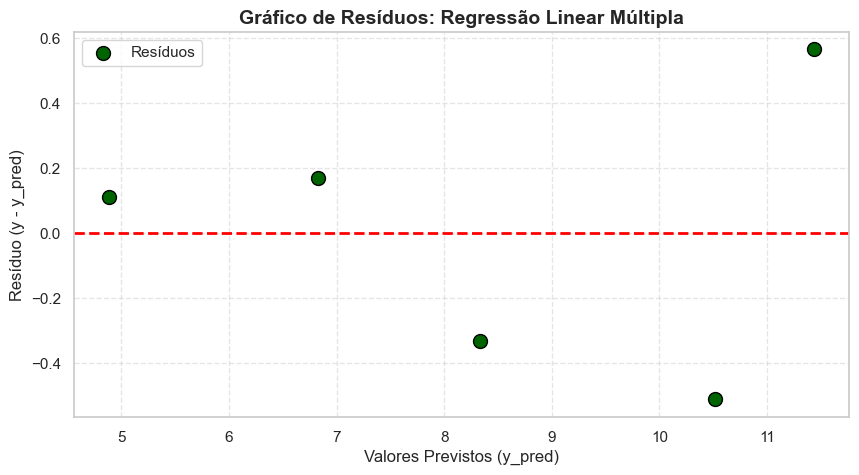

In [4]:
# Fazendo as previsões
previsoes = modelo_multiplo.predict(X_transposta)

# Métricas de ajuste
metricas = ml.rmse(notas, previsoes)
print("=== MÉTRICAS DE AJUSTE (REGRESSÃO MÚLTIPLA) ===")
for k, v in metricas.items():
    print(f"  - {k}: {v:.6f}")

# Resíduos do modelo múltiplo
residuos_multiplos = ml.calcular_erro(notas, previsoes)

# Gráfico de dispersão dos resíduos
plt.figure(figsize=(10, 5))
plt.scatter(previsoes, residuos_multiplos, color='darkgreen', s=100, edgecolors='black', label='Resíduos')
plt.axhline(y=0.0, color='red', linestyle='--', linewidth=2)
plt.title('Gráfico de Resíduos: Regressão Linear Múltipla', fontsize=14, fontweight='bold')
plt.xlabel('Valores Previstos (y_pred)')
plt.ylabel('Resíduo (y - y_pred)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Análise de Homocedasticidade dos Resíduos

Observando o gráfico acima, percebemos que os erros estão dispersos aleatoriamente em torno da reta de erro zero ($y = 0.0$), sem formar padrões de funil (heterocedasticidade) ou formatos curvos. 
Isso valida estatisticamente o nosso modelo de **Regressão Linear Múltipla** como um estimador robusto e eficiente de mínimos quadrados ordinários!